In [3]:
import pandas as pd
from collections import Counter
from collections import Counter
import numpy as np
from ase import Atoms
from dscribe.descriptors import SOAP
import numpy as np

import pandas as pd
import numpy as np
import pymatgen
from pymatgen.core import Element
from mendeleev import element

import ast
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [4]:

df_ABC3 = pd.read_csv("../ABC3_filtered.csv", usecols= ['formula_pretty','elements', 'band_gap','energy_above_hull','formation_energy_per_atom','density',"structure.sites"])
df_ABC3.to_csv("df_ABC3.csv", index=False)
df_ABC3 = pd.read_csv("df_ABC3.csv")

df_A2BCX6 = pd.read_csv("../A2BCX6_filtered.csv", usecols= ['formula_pretty','elements', 'band_gap','energy_above_hull','formation_energy_per_atom','density',"structure.sites"])
df_A2BCX6.to_csv("df_A2BCX6.csv", index=False)
df_A2BCX6 = pd.read_csv("df_A2BCX6.csv")

df_raw = pd.concat([df_ABC3, df_A2BCX6], axis=0,ignore_index=True)
df_raw.to_csv("df_raw.csv", index=False) 
df_raw = pd.read_csv("df_raw.csv")

df_leadfree_raw = df_raw[df_raw['formula_pretty'].apply(lambda x: 'Pb' not in x if isinstance(x, str) else False)]
df_leadfree_raw.to_csv("df_leadfree_raw.csv", index=False)
df_leadfree_raw = pd.read_csv("df_leadfree_raw.csv")

df_ABC3_leadfree = df_ABC3[df_ABC3['formula_pretty'].apply(lambda x: 'Pb' not in x if isinstance(x, str) else False)]
df_ABC3_leadfree.to_csv("df_ABC3_leadfree_raw.csv", index=False)
df_ABC3_leadfree_raw = pd.read_csv("df_ABC3_leadfree_raw.csv")

df_A2BCX6_leadfree = df_A2BCX6[df_A2BCX6['formula_pretty'].apply(lambda x: 'Pb' not in x if isinstance(x, str) else False)]
df_A2BCX6_leadfree.to_csv("df_A2BCX6_leadfree_raw.csv", index=False)
df_A2BCX6_leadfree_raw = pd.read_csv("df_A2BCX6_leadfree_raw.csv")

# saving and reading every dataframe becuase i got wierd type issues and i tried to fix it but could so i just hard coded it 




In [5]:
missing_fusion_heats = {
    "As": 24.44,  # kJ/mol
    "O" : 0.44,
    "N" : 0.72,
    "C" : 117,
    "Ru" : 38.59,
    "Tb" : 10.15,
    "Gd" : 10.05,
    "Dy" : 11.06,
    "Eu" : 9.21,
    "Ho" : 17.0,
    "Er" : 19.9,
    "Lu" : 22,
    "Tm" : 16.84
}

from mendeleev import element

def get_fusion_heat(element_symbol):
    elmt = element(element_symbol)
    if elmt.fusion_heat is None and element_symbol in missing_fusion_heats:
        return missing_fusion_heats[element_symbol]
    elif elmt.fusion_heat is None and element_symbol not in missing_fusion_heats:
        print(elmt.name, "is missing fusion heat value")
    else:
        return elmt.fusion_heat

missing_evaporation_heats = {
    "O" : 6.82, # kJ/mol
    "N" : 5.58,
    "C" : 715,
    "Ru" : 619,
    "Tb" : 391
}

from mendeleev import element

def get_evaporation_heat(element_symbol):
    elmt = element(element_symbol)
    if elmt.evaporation_heat is None and element_symbol in missing_evaporation_heats:
        return missing_evaporation_heats[element_symbol]
    else:
        return elmt.evaporation_heat

missing_specific_heats = {
    "Pa" : 99.1,
    "Tc" : 63
}

def get_specific_heat(element_symbol):
    elmt = element(element_symbol)
    if elmt.specific_heat is None and element_symbol in missing_specific_heats:
        return missing_specific_heats[element_symbol]
    else:
        return elmt.specific_heat

def get_boiling_point(element_symbol):
    elmt = element(element_symbol)
    if element_symbol == "Pa":
        return 4000
    elif element_symbol == "P":
        return 550
    else:
        return elmt.boiling_point
    


def get_atomic_radius_calculated(elmt_pymatgen_temp):
    atomic_radius_calculated_temp = elmt_pymatgen_temp.atomic_radius_calculated
    if atomic_radius_calculated_temp == None:
        return elmt_pymatgen_temp.atomic_radius
    else :
      return atomic_radius_calculated_temp

def get_density_of_solid(elmt_pymatgen_temp):
    density_of_solid_temp = elmt_pymatgen_temp.density_of_solid
    if density_of_solid_temp == None:
        return elmt_pymatgen_temp.atomic_mass / elmt_pymatgen_temp.molar_volume *1000
    else :
      return density_of_solid_temp

In [6]:
#create dictionary with the values for all elements (so that the loop over all formulas is faster) (takes approx 4 minutes now)

#find all elements in the csv file to create input for dictionary creation
# elements_list = pd.read_csv('df.csv', usecols= ['elements'])
  # Select only the 'elements' column

def get_elemental_properties(df):
    elements_list = df[['elements']]
    elements_vector = []
    for index in elements_list.index: # Iterate over DataFrame index to get row
        formula = elements_list.loc[index, 'elements'] # Access element string using loc
        formula = ast.literal_eval(formula) # Safely evaluate string as list
        for elmt in formula:
            elements_vector.append(elmt)

    elements_vector = pd.Series(elements_vector).drop_duplicates().tolist() # Deduplicate elements


    #loop over the found unique elements and define the needed properties
    elemental_properties = {}  #dictionary to be filled

    for symbol in elements_vector:
        #define strings as "elements"
        elmt_pymatgen = Element(symbol)
        elmt_mendeleev = element(symbol)

        properties = {
            'atomic_mass': elmt_pymatgen.atomic_mass,
            'Z': elmt_pymatgen.Z,
            'group': elmt_pymatgen.group,
            'fusion_heat': get_fusion_heat(symbol),  # Use custom function
            'evaporation_heat': get_evaporation_heat(symbol),  # Use custom function
            'specific_heat': get_specific_heat(symbol), # Use custom function
            'row': elmt_pymatgen.row,
            'mendeleev_no': elmt_pymatgen.mendeleev_no,
            'iupac_ordering': elmt_pymatgen.iupac_ordering,
            'average_ionic_radius': elmt_pymatgen.average_ionic_radius,
            'atomic_radius': elmt_pymatgen.atomic_radius,
            'atomic_radius_calculated': get_atomic_radius_calculated(elmt_pymatgen), # Use custom function
            'van_der_waals_radius': elmt_pymatgen.van_der_waals_radius,
            'X': elmt_pymatgen.X,
            'electron_affinity': elmt_pymatgen.electron_affinity,
            'ionization_energy': elmt_pymatgen.ionization_energy,
        #    'valence': elmt_pymatgen.valence[1],
            'density_of_solid': get_density_of_solid(elmt_pymatgen), # Use custom function
            'molar_volume': elmt_pymatgen.molar_volume,
            'boiling_point': get_boiling_point(symbol), # Use custom function
            'melting_point': elmt_pymatgen.melting_point,
            'thermal_conductivity': elmt_pymatgen.thermal_conductivity

        }

        elemental_properties[symbol] = properties  # For dictionary
    return elemental_properties



    


In [7]:

def get_df (df_1, elemental_properties):
  df = df_1.copy()
  #select only te importnat columns from the datafram:
  df = df[['formula_pretty','elements', 'band_gap','energy_above_hull','formation_energy_per_atom','density','structure.sites']]
  index = -1
  for formula in df["elements"]:
    index += 1
    #reformat to list
    elements = ast.literal_eval(formula)

    #calculate property and mean/sd
    atomic_mass = []
    Z = []
    group = []
    row = []
    mendeleev_no = []
    iupac_ordering = []
    average_ionic_radius = []
    atomic_radius = []
    atomic_radius_calculated = []
    van_der_waals_radius = []
    X = []
    electron_affinity = []
    ionization_energy = []
    valence = []
    atomic_mass = []
    density_of_solid = []
    molar_volume = []
    fusion_heat = []
    evaporation_heat = []
    specific_heat = []

#use the library to assign the properties
    for elmt in elements:

      atomic_mass.append(elemental_properties[elmt]['atomic_mass'])
      Z.append(elemental_properties[elmt]['Z'])
      group.append(elemental_properties[elmt]['group'])
      row.append(elemental_properties[elmt]['row'])
      mendeleev_no.append(elemental_properties[elmt]['mendeleev_no'])
      iupac_ordering.append(elemental_properties[elmt]['iupac_ordering'])
      average_ionic_radius.append(elemental_properties[elmt]['average_ionic_radius'])
      atomic_radius.append(elemental_properties[elmt]['atomic_radius'])
      atomic_radius_calculated.append(elemental_properties[elmt]['atomic_radius_calculated'])
      van_der_waals_radius.append(elemental_properties[elmt]['van_der_waals_radius'])
      X.append(elemental_properties[elmt]['X'])
      electron_affinity.append(elemental_properties[elmt]['electron_affinity'])
      ionization_energy.append(elemental_properties[elmt]['ionization_energy'])
      #valence.append(elmt.valence[1])
      density_of_solid.append(elemental_properties[elmt]['density_of_solid'])
      molar_volume.append(elemental_properties[elmt]['molar_volume'])
      fusion_heat.append(elemental_properties[elmt]['fusion_heat'])
      evaporation_heat.append(elemental_properties[elmt]['evaporation_heat'])
      specific_heat.append(elemental_properties[elmt]['specific_heat'])

    mean_atomic_mass = np.mean(atomic_mass)
    std_atomic_mass = np.std(atomic_mass)
    mean_Z = np.mean(Z)
    std_Z = np.std(Z)
    mean_group = np.mean(group)
    std_group = np.std(group)
    mean_row = np.mean(row)
    std_row = np.std(row)
    mean_mendeleev_no = np.mean(mendeleev_no)
    std_mendeleev_no = np.std(mendeleev_no)
    mean_iupac_ordering = np.mean(iupac_ordering)
    std_iupac_ordering = np.std(iupac_ordering)
    mean_average_ionic_radius = np.mean(average_ionic_radius)
    std_average_ionic_radius = np.std(average_ionic_radius)
    mean_atomic_radius = np.mean(atomic_radius)
    std_atomic_radius = np.std(atomic_radius)
    mean_atomic_radius_calculated = np.mean(atomic_radius_calculated)
    std_atomic_radius_calculated = np.std(atomic_radius_calculated)
    mean_van_der_waals_radius = np.mean(van_der_waals_radius)
    std_van_der_waals_radius = np.std(van_der_waals_radius)
    mean_X = np.mean(X)
    std_X = np.std(X)
    mean_electron_affinity = np.mean(electron_affinity)
    std_electron_affinity = np.std(electron_affinity)
    mean_ionization_energy = np.mean(ionization_energy)
    std_ionization_energy = np.std(ionization_energy)
    #mean_valence = np.mean(valence)   ##valence not working yet because of ambiguity
    #std_valence = np.std(valence)
    mean_density_of_solid = np.mean(density_of_solid)
    std_density_of_solid = np.std(density_of_solid)
    mean_molar_volume = np.mean(molar_volume)
    std_molar_volume = np.std(molar_volume)
    mean_fusion_heat = np.mean(fusion_heat)
    std_fusion_heat = np.std(fusion_heat)
    mean_evaporation_heat = np.mean(evaporation_heat)
    std_evaporation_heat = np.std(evaporation_heat)
    mean_specific_heat = np.mean(specific_heat)
    std_specific_heat = np.std(specific_heat)

    #add to dataframe
    df.at[index, 'atom_mass_mean'] = mean_atomic_mass
    df.at[index, 'atom_mass_std'] = std_atomic_mass
    df.at[index, 'Z_mean'] = mean_Z
    df.at[index, 'Z_std'] = std_Z
    df.at[index, 'group_mean'] = mean_group
    df.at[index, 'group_std'] = std_group
    df.at[index, 'row_mean'] = mean_row
    df.at[index, 'row_std'] = std_row
    df.at[index, 'mendeleev_no_mean'] = mean_mendeleev_no
    df.at[index, 'mendeleev_no_std'] = std_mendeleev_no
    df.at[index, 'iupac_ordering_mean'] = mean_iupac_ordering
    df.at[index, 'iupac_ordering_std'] = std_iupac_ordering
    df.at[index, 'average_ionic_radius_mean'] = mean_average_ionic_radius
    df.at[index, 'average_ionic_radius_std'] = std_average_ionic_radius
    df.at[index, 'atomic_radius_mean'] = mean_atomic_radius
    df.at[index, 'atomic_radius_std'] = std_atomic_radius
    df.at[index, 'atomic_radius_calculated_mean'] = mean_atomic_radius_calculated
    df.at[index, 'atomic_radius_calculated_std'] = std_atomic_radius_calculated
    df.at[index, 'van_der_waals_radius_mean'] = mean_van_der_waals_radius
    df.at[index, 'van_der_waals_radius_std'] = std_van_der_waals_radius
    df.at[index, 'X_mean'] = mean_X
    df.at[index, 'X_std'] = std_X
    df.at[index, 'electron_affinity_mean'] = mean_electron_affinity
    df.at[index, 'electron_affinity_std'] = std_electron_affinity
    df.at[index, 'ionization_energy_mean'] = mean_ionization_energy
    df.at[index, 'ionization_energy_std'] = std_ionization_energy
    #df.at[index, 'valence_mean'] = mean_valence
    #df.at[index, 'valence_std'] = std_valence
    df.at[index, 'density_of_solid_mean'] = mean_density_of_solid
    df.at[index, 'density_of_solid_std'] = std_density_of_solid
    df.at[index, 'molar_volume_mean'] = mean_molar_volume
    df.at[index, 'molar_volume_std'] = std_molar_volume
    df.at[index, 'fusion_heat_mean'] = mean_fusion_heat
    df.at[index, 'fusion_heat_std'] = std_fusion_heat
    df.at[index, 'evaporation_heat_mean'] = mean_evaporation_heat
    df.at[index, 'evaporation_heat_std'] = std_evaporation_heat
    df.at[index, 'specific_heat_mean'] = mean_specific_heat
    df.at[index, 'specific_heat_std'] = std_specific_heat
  return df

# df = pd.read_csv('df.csv', usecols= ['formula_pretty','elements', 'band_gap','energy_above_hull','formation_energy_per_atom','density','structure.sites'])




# Save the updated DataFrame to a new CSV file
# Display the updated dataframe
#df

In [8]:

def get_data (df):
    # expects a dataframe with the following columns: "elements", "structure.sites"

    # returns a dataframe where the elements and structure.sites string are plit and unnecessary character removed

    df_curated = pd.DataFrame()

    # df["elements"] = df["elements"].apply(lambda x: x if isinstance(x, str) else "")
    # this line above seems to be important so that we can split the string, but this creates a problem later on, where we get an elemntal entry that is '' so nothing
    # df = df[df["elements"].apply(lambda x: isinstance(x, str))]


    
    df_curated["Elements"] = df["elements"]

    # df_curated["band_gap"] = df["band_gap"]
    # df_curated["formula_pretty"] = df["formula_pretty"]
    # df["structure.sites"] = df["structure.sites"].apply(lambda x: x if isinstance(x, str) else "")
    df_curated["structure_string"] = df["structure.sites"]
    df_curated["structure_string_split"] = None
    


    for i in range(df_curated.shape[0]):
        

        df_curated["structure_string_split"].iloc[i] = df_curated["structure_string"].iloc[i].split()
       
        # #cleans the structure string and removes all the unnecessary characters
        for j in range(len(df_curated["structure_string_split"].iloc[i])):


            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("{","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("}","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("[","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("]","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace(":","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace("'","")
            df_curated["structure_string_split"].iloc[i][j] = df_curated["structure_string_split"].iloc[i][j].replace(",","")

        df_curated["Elements"].iloc[i] = df_curated["Elements"].iloc[i].split(",")
        for k in range(len(df_curated["Elements"].iloc[i])):
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("'", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("[", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace("]", "")
            df_curated["Elements"].iloc[i][k] = df_curated["Elements"].iloc[i][k].replace(" ", "")

    print("get data done")
    return df_curated




def split_df (df):
    # expects a dataframe with the following columns: "structure_string_split" where each elements has 18 entires
    # select only the positons with relevant data and store them as a touple of (element, [x,y,z])
    # returns the data frame with the appended column "positions" with the positions of the atoms in the structure


    df["positions"] = None
    for i in range(len(df["structure_string_split"])):
        position_i = []
        for j in range (0, len(df["structure_string_split"].iloc[i]), 18):
            element = df["structure_string_split"].iloc[i][j+2] # remove trailing comma
            x = float(df["structure_string_split"].iloc[i][j+15])
            y = float(df["structure_string_split"].iloc[i][j+16])
            z = float(df["structure_string_split"].iloc[i][j+17])
            position_i.append((element, [x, y, z]))
        df["positions"].iloc[i] = position_i


    print("split df done")
    return df


def get_ratio(df):
    # Input: pd.datafram with a column "positions" containing lists of tuples (element, [x, y, z])
    #
    # Output: appends dataframe with a new column "ratio" containing a sorted dictionary of elements and their ratios
    #
    df["ratio"] = None

    #loops over all entriey in positions
    for i, atom_list in enumerate(df["positions"]):
        elements = [atom[0] for atom in atom_list]
        occurance = Counter(elements)

        counts = np.fromiter(occurance.values(), dtype=int)

        gcd = np.gcd.reduce(counts)


        reduced_occurance = {element: count // gcd for element, count in occurance.items()}

        # Sort by value so largest is last
        sorted_occurrence = dict(sorted(reduced_occurance.items(), key=lambda item: item[1]))

        df["ratio"].iloc[i] = sorted_occurrence

    return df


def get_ase(df):
    # expect a data frame with a column "positions" containing lists of tuples (element, [x, y, z])
    # returns a data frame with a new column "ase" containing ase atoms objects




    df["ase"] = None  # Optional, for clarity
    for i, row in df.iterrows():
        symbols = [atom[0] for atom in row["positions"]]
        positions = [atom[1] for atom in row["positions"]]
        
        atoms_obj = Atoms(symbols=symbols, positions=positions)
        df.at[i, "ase"] = atoms_obj
    return df


def get_soap(df, r_cut=190.0, n_max=2, l_max=2, sigma=1):
    # Automatically extract all unique species from df["Elements"]


    unique_species = sorted(set(e for row in df["Elements"] for e in row))

    # Create SOAP descriptor generator
    soap_generator = SOAP(
        species=unique_species,
        r_cut=r_cut,
        n_max=n_max,
        l_max=l_max,
        sigma=sigma,
        periodic=False,
        sparse=False,
        rbf = "gto"
    )

    # Generate and store SOAP descriptors
    soap_list = []
    for atoms in df["ase"]:
        descriptor = soap_generator.create(atoms)
        #this seems to make every soap have the same length
        avg_descriptor = np.mean(descriptor, axis=0) #check if this is the correct way to do it with stehpan 

        soap_list.append(avg_descriptor)

    df["soap"] = soap_list
    return df


def append_soap(df):
    #combines all the function from above
    # expects a dataframe with the following columns: "elements", "structure.sites"
 
    # retrun the datafram with the soap descriptor column appended at the end 
    df_soap = df.copy()
    df_soap = get_data(df_soap)
    df_soap = split_df(df_soap)
    df_soap = get_ase(df_soap)
    df_soap = get_soap(df_soap)
    df["elements"] = df_soap["Elements"]
    df_soap.drop(columns=["Elements","structure_string", "structure_string_split","positions","ase"], inplace=True)
    df = pd.concat([df, df_soap], axis=1)
    df.drop(columns=["structure.sites"], inplace=True)
    print("append soap done")
  
    return df


def create_df(df):
  df = df.copy()

  elemental_properties = get_elemental_properties(df)

  df = get_df(df,elemental_properties)
  df_soap = append_soap(df)

  print("soap appended")
  return df_soap

# df_soap = create_df(df)


# df_soap



In [51]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from matplotlib import pyplot as plt
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, RandomizedSearchCV, learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.utils import shuffle
from sklearn.feature_selection import SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pylab as pl
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
%matplotlib inline 
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
%matplotlib inline
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance


In [10]:

# X = df_soap.select_dtypes(include=[np.number]).drop(columns=["band_gap"])

# y = np.asarray(df_soap["band_gap"])

# print(X.shape, y.shape)
# print(X)



# big_df_soap = big_df("df_soap", df_soap)

# print(big_df_soap.X)
# print(big_df_soap.y)





In [60]:
class big_df:
    def __init__(self, name, df):
        self.name = name
        self.df = df
        self.X = None
        self.y = None
        self.RMSE = None
        self.RMAE = None
        self.R2_train = None
        self.R2_test = None

    def print(self):
        print("Name: ", self.name)
        print("RMSE: ", self.RMSE)
        print("RMAE: ", self.RMAE)
        print("R2_train: ", self.R2_train)
        print("R2_test: ", self.R2_test)
        print("\n")



    def save_df(self):
        self.df.to_csv(self.name + ".csv", index=False)
        print("saved " +self.name + " to csv")
        return

def train_and_test_svr(big_df_temp, test_size, store = True, plot = False):

    "Input: custom class big_df with the dataframe and the name of the dataframe"
    "Output: creates and adds the X and y, splits the data and then trains the model on the training data. Also evaluates the model on the test data, esureing not dta leakage"
    "Also plots the residuals and prints the feature importances"
    "For the feature importance it expects the soap colums to be split and separatly appended to the dataframe, it summs the imporatnce of each soap up to create the overall soap importances"


    # Beispiel: df['soap'] enthält Vektoren
    # z. B. df['soap'][0] = [0.1, 0.2, 0.3, ..., 1.0]

    # Wandle die Liste von Vektoren in ein 2D-Array
    # soap_array = np.array(big_df_temp.df['soap'].to_list())

    # # Erzeuge neue Spaltennamen
    # soap_columns = [f"soap_{i}" for i in range(soap_array.shape[1])]

    # # Erstelle ein neues DataFrame mit diesen Spalten
    # soap_df = pd.DataFrame(soap_array, columns=soap_columns, index=big_df_temp.df.index)

    big_df_temp.X = big_df_temp.df.select_dtypes(include=[np.number]).drop(columns=["band_gap"])

    big_df_temp.y = np.asarray(big_df_temp.df["band_gap"]) 
        # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(big_df_temp.X, big_df_temp.y, test_size=test_size, random_state=9)
    
    # Create a Random Forest Regressor model
    # Set up pipeline for the grid search (for the support vector regression (SVR))
    steps = [('scaler', StandardScaler()), ('SVM', SVR())]
    pipeline = Pipeline(steps)

    # Perform 5-fold cross-validated gridsearch (for the SVR)
    grid = GridSearchCV(pipeline, param_grid={'SVM__C': [100], 'SVM__gamma': ['auto'],
                                              'SVM__kernel': ['rbf'], 'SVM__epsilon': [0.001]}, cv=5)

    # Fit to the train set and evaluate the model using the test set
    grid.fit(X_train, y_train)

    # Make predictions on the test set
    y_predicted = grid.predict(X_test)

    "Plots the predicted values against the true values"

    if plot:
        plt.figure(figsize=(5, 5))
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
        plt.scatter(y_test, y_predicted)
        plt.xlabel("True Values")
        plt.ylabel("Predictions")
        plt.title("SVR: Band Gap for " + big_df_temp.name)
        plt.savefig(big_df_temp.name + "_SVR_band_gap.png")
        plt.show()


    "look at the feature importance"

    # Permutation Importance
    results = permutation_importance(grid, X_test, y_test, n_repeats=10, random_state=42)
    importances = results.importances_mean

    # Assign Feature Names based on the column names
    if isinstance(X_test, pd.DataFrame):
        feature_names = X_test.columns
    else:
        # Fallback, if X_test is not a dataframe
        feature_names = [f"Feature {i+1}" for i in range(len(importances))]
        print("X_test is not a dataframe.")


    # Dataframe with individual importances
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    # Aggregate all SOAP feature importances into one
    soap_start_index = 39 # Index, ab dem die 'soap' Spalten beginnen (0-basiert)
    soap_columns = feature_names[soap_start_index:]


    # Sum of the SOAP importances
    soap_importance = importance_df[importance_df['Feature'].isin(soap_columns)]['Importance'].sum()

    # Append as a row in the dataframe
    high_level_importance_df = importance_df[~importance_df['Feature'].isin(soap_columns)].copy()
    high_level_importance_df = pd.concat([
        high_level_importance_df,
        pd.DataFrame([{'Feature': 'SOAP', 'Importance': soap_importance}])
    ], ignore_index=True)

    # Sort the importances and show them
    high_level_importance_df = high_level_importance_df.sort_values(by='Importance', ascending=False)

    print("Aggregated Feature Importance (Permutation Importance):")
    print(high_level_importance_df)

    # print("Grouped Feature Importances for " + big_df_temp.name)
    # print(high_level_importance_df.head(5))

    r2_score = grid.score(X_train, y_train)

    r2_score1 = grid.score(X_test, y_test)
    rmse = mean_squared_error(y_test, y_predicted)
    rmae = mean_absolute_error(y_test, y_predicted)
    if store:
        big_df_temp.features = high_level_importance_df
        big_df_temp.R2_train = r2_score
        big_df_temp.R2_test = r2_score1
        big_df_temp.RMSE = rmse
        big_df_temp.RMAE = rmae
        big_df_temp.X_train = X_train
        big_df_temp.X_test = X_test
        big_df_temp.y_train = y_train
        big_df_temp.y_test = y_test
        big_df_temp.print()
        return
    else:

        # print("RMSE: ", rmse)
        # print("RMAE: ", rmae)

        return rmse

# X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.1, random_state=9)
# rfr = GridSearchCV (RandomForestRegressor(),{'max_depth':[None], 'random_state':[0],}, cv=5)
# rfr.fit(X_train, y_train)
# rfr_score = rfr.score(X_train,y_train)
# rfr_score1 = rfr.score(X_test,y_test)
# y_predicted8 = rfr.predict(X_test)
# print('RFR Model| R2 sq on train set: %.4f'% rfr_score)
# print('RFR Model| R2 sq on test set: %.4f'% rfr_score1)
# print('RFR Model| MSE on test set: %.4f'% mean_squared_error(y_test, y_predicted8))
# print('RFR Model| MAE on test set: %.4f'% mean_absolute_error(y_test, y_predicted8))


In [31]:
" this dictionary stores all df that we want to use in the future, makes data handling easier"

all_df = {
    # "df_ABC3_leadfree" : df_ABC3_leadfree_raw,
    # "df_A2BCX6_leadfree" : df_A2BCX6_leadfree_raw,
    "df_leadfree" : df_leadfree_raw,
    # "df_ABC3" : df_ABC3,
    # "df_abundant" : df_abundant_perovskites,
    # "df_A2BCX6" : df_A2BCX6,
    "df" : df_raw
    }

In [55]:
list_big_df = []
for name, df in all_df.items():

    df = create_df(df)
    print("raw df pruned "+ name)
    df.to_csv(name + ".csv", index=False)


    #maybe compress so that it can transer soaps as well,
    # for now its ok since i dont use the created csv here but it could lead to reproducabiity issues
    # maybe safe it before createing the soaps?

    big_df_temp = big_df(name, df)
    big_df_temp.save_df()
    list_big_df.append(big_df_temp)
    # train_and_test_rfr(big_df_temp)
    # print("df trained")

get data done
split df done
append soap done
soap appended
raw df pruned df_leadfree
saved df_leadfree to csv
get data done
split df done
append soap done
soap appended
raw df pruned df
saved df to csv


In [58]:
#Filtering for the elemental abundance

import pandas as pd
import ast

#Defining elemental abundance dictionary (abundance in ppm from https://en.wikipedia.org/wiki/Abundance_of_elements_in_Earth%27s_crust)
elemental_abundance = {
    'Ac' : 0.000000000055,
    'Ag' : 0.075,
    'Al' : 82300,
    'Ar' : 3.5,
    'As' : 1.8,
    'At' : 0.000000000005,
    'Au' : 0.004,
    'B' : 10,
    'Ba' : 425,
    'Be' : 2.8,
    'Bi' : 0.0085,
    'Br' : 2.4,
    'C' : 200,
    'Ca' : 41500,
    'Cd' : 0.15,
    'Ce' : 66.5,
    'Cl' : 145,
    'Co' : 25,
    'Cr' : 102,
    'Cs' : 3,
    'Cu' : 60,
    'Dy' : 5.2,
    'Er' : 3.5,
    'Eu' : 2,
    'F' : 585,
    'Fe' : 56300,
    'Fr' : 0.000000000005,
    'Ga' : 19,
    'Gd' : 6.2,
    'Ge' : 1.5,
    'H' : 1400,
    'He' : 0.008,
    'Hf' : 3.0,
    'Hg' : 0.085,
    'Ho' : 1.3,
    'I' : 0.45,
    'In' : 0.25,
    'Ir' : 0.001,
    'K' : 20900,
    'Kr' : 0.0001,
    'La' : 39,
    'Li' : 20,
    'Lu' : 0.8,
    'Mg' : 23300,
    'Mn' : 950,
    'Mo' : 1.2,
    'N' : 19,
    'Na' : 23600,
    'Nb' : 20,
    'Nd' : 41.5,
    'Ne' : 0.005,
    'Ni' : 84,
    'Np' : 0.00000000005,
    'O' : 461000,
    'Os' : 0.0015,
    'P' : 1050,
    'Pa' : 0.00000000005,
    'Pb' : 14,
    'Pd' : 0.015,
    'Pm' : 0.00000000005,
    'Po' : 0.00000000002,
    'Pr' : 9.2,
    'Pt' : 0.005,
    'Pu' : 0.00000000005,
    'Ra' : 0.0000009,
    'Rb' : 90,
    'Re' : 0.0007,
    'Rh' : 0.001,
    'Rn' : 0.0000000000004,
    'Ru' : 0.001,
    'S' : 350,
    'Sb' : 0.2,
    'Sc' : 22,
    'Se' : 0.05,
    'Si' : 282000,
    'Sm' : 7.05,
    'Sn' : 2.3,
    'Sr' : 370,
    'Ta' : 2.0,
    'Tb' : 1.2,
    'Tc' : 0.0000000005,
    'Te' : 0.001,
    'Th' : 9.6,
    'Ti' : 5650,
    'Tl' : 0.85,
    'Tm' : 0.52,
    'U' : 2.7,
    'V' : 120,
    'W' : 1.25,
    'Xe' : 0.00003,
    'Y' : 33,
    'Yb' : 3.2,
    'Zn' : 70,
    'Zr' : 165
}

# Read in Dataframe
df = list_big_df[1].df.copy()

#def convert_string_to_list(element_string):
#    try:
#        return ast.literal_eval(element_string)
#    except (SyntaxError, ValueError):
#        return []  # Or handle errors as appropriate

# Define your abundance threshold
abundance_threshold = 10  # Example threshold in ppm

def is_abundant_perovskite(elements, abundance_data, threshold):
    """
    Checks if all elements in a list are above the abundance threshold.

    Args:
        elements (list): A list of element symbols from the perovskite composition (e.g., ['Ni', 'O', 'Sr', 'W']).
        abundance_data (dict): A dictionary of elemental abundances (e.g., {'Ni': 84, ...}).
        threshold (float): The minimum abundance threshold.

    Returns:
        bool: True if all elements are above the threshold, False otherwise.
    """
    for element in elements:
        if element in abundance_data and abundance_data[element] <= threshold:
            return False
        elif element not in abundance_data:
            print(f"Warning: Abundance data not found for element '{element}'. Assuming it's not abundant.")
            return False  # Or you could choose to handle missing data differently
    return True

if 'elements' in df.columns:
    #df['elements'] = df['elements'].apply(convert_string_to_list)

    # Apply the function to each row of the DataFrame
    abundant_mask = df['elements'].apply(lambda x: is_abundant_perovskite(x, elemental_abundance, abundance_threshold))

    # Filter the DataFrame using the boolean mask
    df_abundant_perovskites = df[abundant_mask]

    print(f"Original DataFrame shape: {df.shape}")
    print(f"Filtered DataFrame shape (threshold = {abundance_threshold} ppm): {df_abundant_perovskites.shape}")
    # Now 'abundant_perovskites_df' contains only the structures where all elements
    # have a natural abundance greater than or equal to the threshold.
    # print(abundant_perovskites_df.head())
else:
    print("Error: The 'elements' column was not found in the DataFrame.")

#Apply Function
df_abundant = big_df("df_abundant", df_abundant_perovskites)
df_abundant.save_df()

#Append to big dataframe
list_big_df.append(df_abundant)

Original DataFrame shape: (1424, 43)
Filtered DataFrame shape (threshold = 10 ppm): (385, 43)
saved df_abundant to csv


In [59]:
def find_best_split(list_big_df):
    "Input: list of big_df objects"
    "Output: Finds the best train test split for each dataframe and returns the split value and the RMSE"


    for df in list_big_df:
        max_RMSE = 10
        best_split = 0
        for i in np.linspace(0.1,0.9,num = 9):
            i = float(i)
            # print("test size: ", i)
            # False means the RMSE is return and the values are not stored in the big_df classxvx
            RMSE = train_and_test_svr(df,i,False)
            if RMSE < max_RMSE:
                max_RMSE = RMSE
                best_split = i
        print("Best split for " + df.name + " is: ", best_split)
        print("Best RMSE for " + df.name + " is: ", max_RMSE)

    return
    # df.print()

find_best_split(list_big_df)

Aggregierte Feature-Wichtigkeiten (Permutation Importance):
                          Feature  Importance
1       formation_energy_per_atom    2.214017
7                      group_mean    0.780915
17             atomic_radius_mean    0.499783
14             iupac_ordering_std    0.407103
5                          Z_mean    0.335481
8                       group_std    0.316978
36           evaporation_heat_std    0.297132
29          density_of_solid_mean    0.290330
22       van_der_waals_radius_std    0.282159
9                        row_mean    0.277726
2                         density    0.275313
31              molar_volume_mean    0.267345
26          electron_affinity_std    0.248663
25         electron_affinity_mean    0.238959
32               molar_volume_std    0.226810
18              atomic_radius_std    0.202647
30           density_of_solid_std    0.199589
24                          X_std    0.186262
13            iupac_ordering_mean    0.171117
12               men

KeyboardInterrupt: 

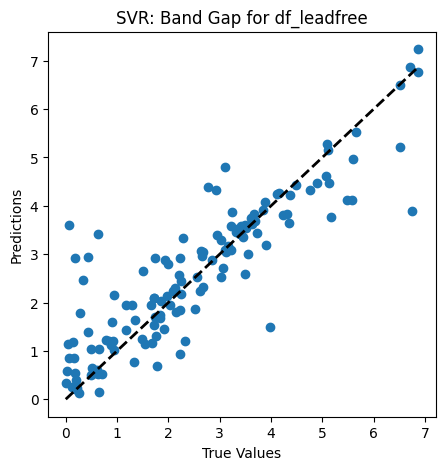

Aggregated Feature Importance (Permutation Importance):
                          Feature  Importance
1       formation_energy_per_atom    2.214017
7                      group_mean    0.780915
17             atomic_radius_mean    0.499783
14             iupac_ordering_std    0.407103
5                          Z_mean    0.335481
8                       group_std    0.316978
36           evaporation_heat_std    0.297132
29          density_of_solid_mean    0.290330
22       van_der_waals_radius_std    0.282159
9                        row_mean    0.277726
2                         density    0.275313
31              molar_volume_mean    0.267345
26          electron_affinity_std    0.248663
25         electron_affinity_mean    0.238959
32               molar_volume_std    0.226810
18              atomic_radius_std    0.202647
30           density_of_solid_std    0.199589
24                          X_std    0.186262
13            iupac_ordering_mean    0.171117
12               mendele

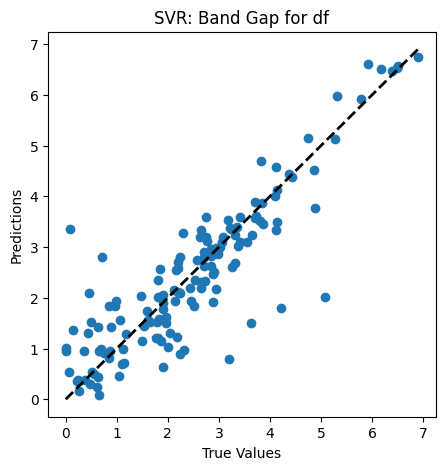

Aggregated Feature Importance (Permutation Importance):
                          Feature  Importance
1       formation_energy_per_atom    2.245922
7                      group_mean    1.005323
17             atomic_radius_mean    0.923631
8                       group_std    0.466890
9                        row_mean    0.387048
36           evaporation_heat_std    0.335648
32               molar_volume_std    0.329326
14             iupac_ordering_std    0.299023
5                          Z_mean    0.276178
29          density_of_solid_mean    0.265356
13            iupac_ordering_mean    0.258271
22       van_der_waals_radius_std    0.241545
26          electron_affinity_std    0.225291
2                         density    0.222785
31              molar_volume_mean    0.221918
21      van_der_waals_radius_mean    0.187448
27         ionization_energy_mean    0.187069
25         electron_affinity_mean    0.180035
18              atomic_radius_std    0.178266
24                      

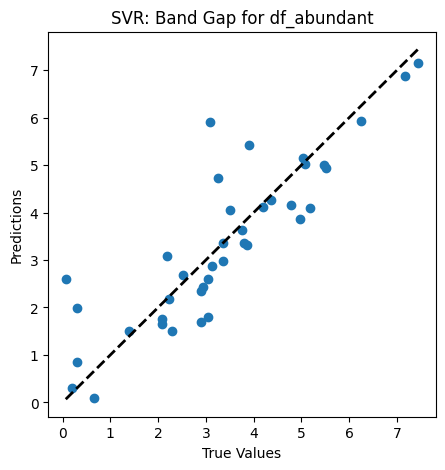

Aggregated Feature Importance (Permutation Importance):
                          Feature  Importance
1       formation_energy_per_atom    1.251710
35          evaporation_heat_mean    0.491443
21      van_der_waals_radius_mean    0.406343
17             atomic_radius_mean    0.356785
34                fusion_heat_std    0.221616
16       average_ionic_radius_std    0.171767
0               energy_above_hull    0.159117
2                         density    0.135445
6                           Z_std    0.117521
5                          Z_mean    0.107935
32               molar_volume_std    0.107724
23                         X_mean    0.092511
25         electron_affinity_mean    0.087129
31              molar_volume_mean    0.078277
33               fusion_heat_mean    0.076420
7                      group_mean    0.075485
27         ionization_energy_mean    0.074316
30           density_of_solid_std    0.073924
9                        row_mean    0.069547
4                   atom

In [64]:
for df in list_big_df:
    train_and_test_svr(df, test_size = 0.1, store = True, plot = True)
    df.print()


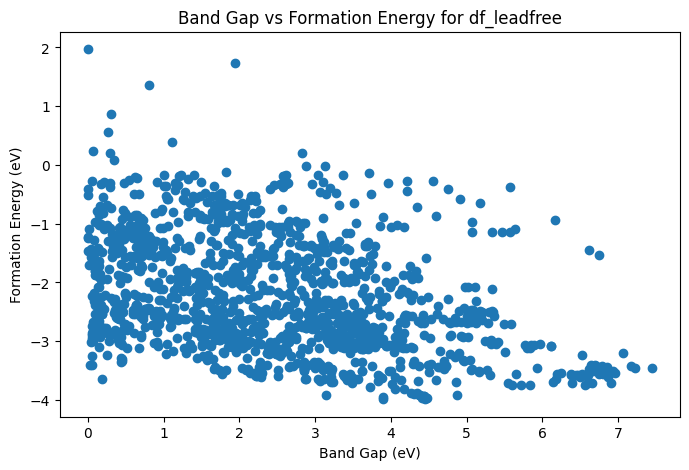

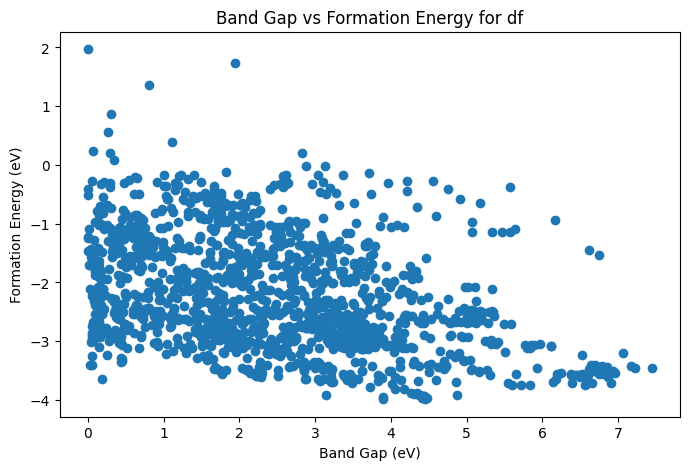

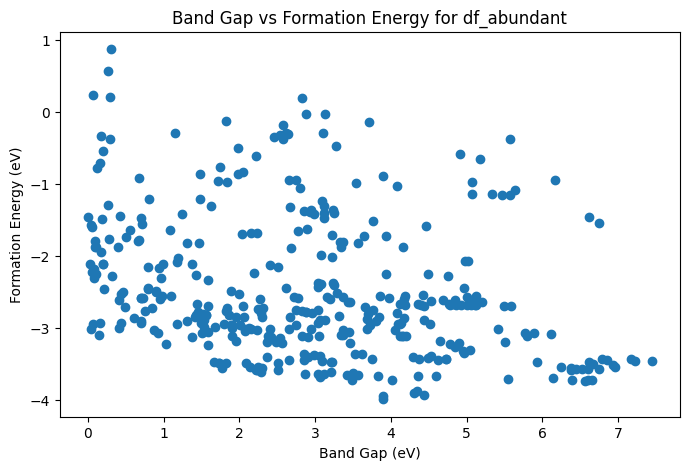

In [65]:
def plot_bg_vs_FE (big_df_list):
    # expects a list of big_df objects
    # plots the band gap vs formation energy for each dataframe in the list
    # saves the plot as a png file
    # returns nothing

    for df in big_df_list:
        plt.figure(figsize=(8, 5))
        plt.scatter( df.df["band_gap"],df.df["formation_energy_per_atom"])
        plt.ylabel("Formation Energy (eV)")
        plt.xlabel("Band Gap (eV)")
        plt.title("Band Gap vs Formation Energy for " + df.name)
        plt.savefig(df.name + "_band_gap_vs_FE.png")
        plt.show()


plot_bg_vs_FE(list_big_df)


In [66]:
#store the RMAE and RMSE in a dataframe with colums names from the dataset it came from
def store_RMAE_RMSE(big_df_list):
    # expects a list of big_df objects
    # stores the RMSE and RMAE in a dataframe with colums names from the dataset it came from
    # returns the dataframe

    df = pd.DataFrame(columns=["dataset", "RMSE", "RMAE"])
    for df_temp in big_df_list:
        df = df.append({"dataset": df_temp.name, "RMSE": df_temp.RMSE, "RMAE": df_temp.RMAE}, ignore_index=True)
    return df

store_RMAE_RMSE(list_big_df)

AttributeError: 'DataFrame' object has no attribute 'append'

In [ ]:

# Parameter grid for hyperparameter search

p_grid = {"n_estimators": [10,100,1000], "max_depth": [None,10,20,30]}
# Initialise the Random Forest classifier
rf = RandomForestRegressor(random_state=22)

# Initialise KFold
kf = KFold(n_splits=5, shuffle=True, random_state=12)

# GridSearch CV
gs = GridSearchCV(estimator=rf, param_grid=p_grid, cv=kf, scoring='neg_mean_squared_error')

gs.fit(X_train, y_train)
RMSE_neg = cross_val_score(gs, X=X_train, y=y_train, cv=kf, scoring='neg_mean_squared_error')
RMSE = np.sqrt(-RMSE_neg)

# Define model with best hyperparameters and print them
model = gs.best_estimator_
print(f"Hyperparameters: {gs.best_params_}\n")


# p_grid = {"n_estimators": [10,15,30], "max_depth": [None,10,20]}
# Hyperparameters: {'max_depth': 20, 'n_estimators': 30}


In [ ]:

rfr = GridSearchCV (RandomForestRegressor(),{'max_depth':[20], 'n_estimators': [30], 'random_state':[0],}, cv=5)
rfr.fit(X_train, y_train)
rfr_score = rfr.score(X_train,y_train)
rfr_score1 = rfr.score(X_test,y_test)
y_predicted8 = rfr.predict(X_test)
print('RFR Model| R2 sq on train set: %.4f'% rfr_score)
print('RFR Model| R2 sq on test set: %.4f'% rfr_score1)
print('RFR Model| MSE on test set: %.4f'% mean_squared_error(y_test, y_predicted8))
print('RFR Model| MAE on test set: %.4f'% mean_absolute_error(y_test, y_predicted8))

In [ ]:
from sklearn import metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_model_with_cv(model, X, y, random_state):
    """
    Evaluate a model using 5-fold cross-validation and return performance metrics.

    Parameters:
        model: The model to evaluate
        X: Feature matrix
        y: Target vector
        random_state: Random seed for reproducibility

    Returns:
        Dictionary with performance metrics and arrays of per-fold metrics
    """
    # Initialize KFold
    kf = KFold(n_splits=5, shuffle=True, random_state=random_state)

    # Lists to store metrics
    metrics = {
        'RMSEs': [],
    }

    # Create figure for ROC curves
    plt.figure()

    # Iterate over folds
    for k, (train_index, test_index) in enumerate(kf.split(X)):
        # Split data
        X_train_fold, X_test_fold = X[train_index], X[test_index]
        y_train_fold, y_test_fold = y[train_index], y[test_index]

        # Train model
        model.fit(X_train_fold, y_train_fold)

        # Predict
        y_pred_fold = model.predict(X_test_fold)

        # Calculate metrics
        metrics['RMSEs'].append(mean_squared_error(y_test_fold, y_pred_fold))
     

        # ROC curve

    # Print metrics
    metric_display_names = {
        'RMSEs': 'RMSE',
     
    }
    for metric_name, values in metrics.items():
        display_name = metric_display_names[metric_name]
        print(f"Average {display_name}: {np.mean(values):.4f} \t and std err: {stats.sem(values):.4f}")

    return metrics

In [ ]:
metrics_rf = evaluate_model_with_cv(model, X, y, random_state=22)

In [ ]:
plt.hist(y, bins=50)
plt.xlabel("Band Gap (eV)")
plt.show()
plt.hist(df_soap["energy_above_hull"], bins=50)
plt.xlabel("Energy Above Hull (eV)")
plt.ylim(0, 20)
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
import sklearn.datasets
import umap.plot


In [ ]:

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.title("PCA Projection")
plt.show()

# UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_train)
pendigits = sklearn.datasets.load_digits()
mnist = sklearn.datasets.fetch_openml('mnist_784')
fmnist = sklearn.datasets.fetch_openml('Fashion-MNIST')
mapper = umap.UMAP().fit(pendigits.data)
umap.plot.points(mapper, labels=pendigits.target,theme='fire')  


# plt.scatter(X_umap[:, 0], X_umap[:, 1])
# plt.title("UMAP Projection")
# plt.show()


In [ ]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# Fit PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# Get loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X_train.columns
)

# Sort by absolute value of PC1/PC2
top_features_pc1 = loadings["PC1"].abs().sort_values(ascending=False)
top_features_pc2 = loadings["PC2"].abs().sort_values(ascending=False)

# Print top contributors
print("Top PC1 contributors:\n", top_features_pc1.head())
print("\nTop PC2 contributors:\n", top_features_pc2.head())

# Optional: plot as a biplot
plt.figure(figsize=(80, 60))
plt.quiver(np.zeros(loadings.shape[0]), np.zeros(loadings.shape[0]),
           loadings["PC1"], loadings["PC2"],
           angles='xy', scale_units='xy', scale=1)
for i, feature in enumerate(loadings.index):
    plt.text(loadings["PC1"][i], loadings["PC2"][i], feature, fontsize=9)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Loadings Biplot")
plt.grid(True)
plt.show()


In [ ]:
X_umap = mapper.embedding_  # assuming UMAP already fit

# Create DataFrame of UMAP components
umap_df = pd.DataFrame(X_umap, columns=["UMAP1", "UMAP2"])

# Correlation between features and UMAP axes
correlations = pd.concat([
    X_train.reset_index(drop=True).corrwith(umap_df["UMAP1"]).abs().rename("UMAP1"),
    X_train.reset_index(drop=True).corrwith(umap_df["UMAP2"]).abs().rename("UMAP2")
], axis=1)

print("Top contributors to UMAP1:\n", correlations["UMAP1"].sort_values(ascending=False).head())
print("\nTop contributors to UMAP2:\n", correlations["UMAP2"].sort_values(ascending=False).head())


In [ ]:
import pandas as pd
import numpy as np
import ast
import umap.plot

# Create hoverable element strings
df_soap["elements_str"] = df_soap["elements"].apply(
    lambda x: ', '.join(ast.literal_eval(x)) if isinstance(x, str) else str(x)
)

# Build hover data
hover_data = pd.DataFrame({
    "index": np.arange(len(df_soap)),
    "formula": df_soap["formula_pretty"],
    "elements": df_soap["elements_str"]
})

# Fire-themed UMAP with coloring by nearest neighbor distances
p = umap.plot.interactive(
    mapper,
    hover_data=hover_data,
    point_size=5,
    labels=pendigits.target,
    theme="fire"
)

umap.plot.show(p)



In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV

# Ridge
ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0], cv=5)
ridge.fit(X_train, y_train)

# Lasso
lasso = LassoCV(alphas=[0.01, 0.1, 1.0, 10.0], cv=5)
lasso.fit(X_train, y_train)

# ElasticNet
elastic = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, 1], cv=5)
elastic.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error, r2_score

# Evaluate Ridge
ridge_preds = ridge.predict(X_test)
print("Ridge R²:", r2_score(y_test, ridge_preds))
print("Ridge RMSE:", mean_squared_error(y_test, ridge_preds, squared=False))

# Evaluate Lasso
lasso_preds = lasso.predict(X_test)
print("Lasso R²:", r2_score(y_test, lasso_preds))
print("Lasso RMSE:", mean_squared_error(y_test, lasso_preds, squared=False))

# Evaluate ElasticNet
elastic_preds = elastic.predict(X_test)
print("ElasticNet R²:", r2_score(y_test, elastic_preds))
print("ElasticNet RMSE:", mean_squared_error(y_test, elastic_preds, squared=False))



In [ ]:
ridge = ElasticNetCV(cv=5).fit(X_train, y_train)

# Select only non-zero coefficient features
selected_features = X_train.columns[ridge.coef_ != 0]

print("Selected features:", selected_features)

X_train_ridge = X_train[selected_features]
y_train_ridge = y_train
X_test_ridge = X_test[selected_features]
rfr = GridSearchCV (RandomForestRegressor(),{'max_depth':[None], 'random_state':[0],}, cv=5)
rfr.fit(X_train_ridge, y_train_ridge)
rfr_score = rfr.score(X_train_ridge,y_train_ridge)
rfr_score1 = rfr.score(X_test_ridge,y_test)
y_predicted8 = rfr.predict(X_test_ridge)
print('RFR Model| R2 sq on train set: %.4f'% rfr_score)
print('RFR Model| R2 sq on test set: %.4f'% rfr_score1)
print('RFR Model| MSE on test set: %.4f'% mean_squared_error(y_test, y_predicted8))
print('RFR Model| MAE on test set: %.4f'% mean_absolute_error(y_test, y_predicted8))

This is the score without any regularisation 

RFR Model| R2 sq on train set: 0.9594
RFR Model| R2 sq on test set: 0.7289
RFR Model| MSE on test set: 0.6408
RFR Model| MAE on test set: 0.6078

and this is it with 

RFR Model| R2 sq on train set: 0.9162
RFR Model| R2 sq on test set: 0.5136
RFR Model| MSE on test set: 1.1497
RFR Model| MAE on test set: 0.8151

clearly the regularisation with lasso/elasticnet made the model worse

regularization with ridge did not cahnge a thing 
